In [29]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import Bunch
from sklearn.metrics import precision_score, accuracy_score, recall_score
from sklearn.linear_model import LogisticRegressionCV
import numpy as np
from typing import Any
import math

import matplotlib.pyplot as plt
import seaborn as sns

## About the Dataset

In [32]:
abalone = fetch_ucirepo(id=1)
X: Any = abalone.data.features
y: Any = abalone.data.targets

Vì dữ liệu target đang ở dạng số, nên ta cố gắng đưa nó thành các class thông qua quan sát biểu đồ phân phối

<Axes: ylabel='Frequency'>

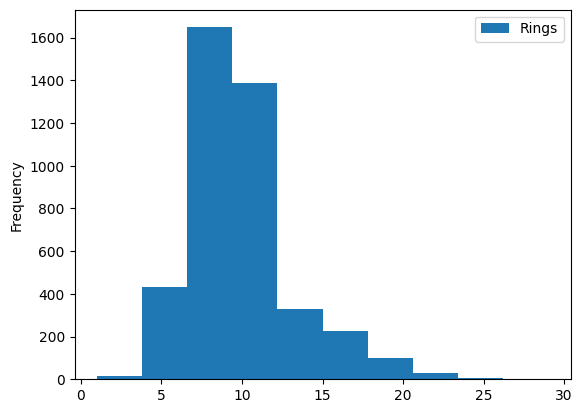

In [38]:
y.plot.hist()

Từ biểu đồ trên ta có thể chia dữ liệu thành 5 class:
- Class 1: 0 <= x < 5
- Class 2: 5 <= x < 10
- Class 3: 10 <= x < 15
- Class 4: 15 <= x < 20
- Class 5: x >= 20

In [45]:
def mapping(x: float) -> int:
    if x >= 0:
        if x < 5:
            return 1
        elif x < 10:
            return 2
        elif x < 15:
            return 3
        elif x < 20:
            return 4
        else:
            return 5

y.Rings.apply(mapping)

0       4
1       2
2       2
3       3
4       2
       ..
4172    3
4173    3
4174    2
4175    3
4176    3
Name: Rings, Length: 4177, dtype: int64

In [3]:
df: dict[str, Any] = {
    "sepal length": iris.data[:, 0],
    "sepal width": iris.data[:, 1],
    "petal length": iris.data[:, 2],
    "pepal width": iris.data[:, 3],
    "class": iris.target
}
df = pd.DataFrame(data=df)
df.head()

,sepal length,sepal width,petal length,pepal width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Remove flowers have missing values

# Get flowers have missing values
remove_flowers: Any = df.isnull().any(axis=1)

# Remove missing values
# rmv_df: Removed_missing_value_data_frame
rmv_df = df[remove_flowers==0]

# Check the number of flowers removed

print("Number of rows removed is: ", sum(remove_flowers))

Number of rows removed is:  0


<Axes: >

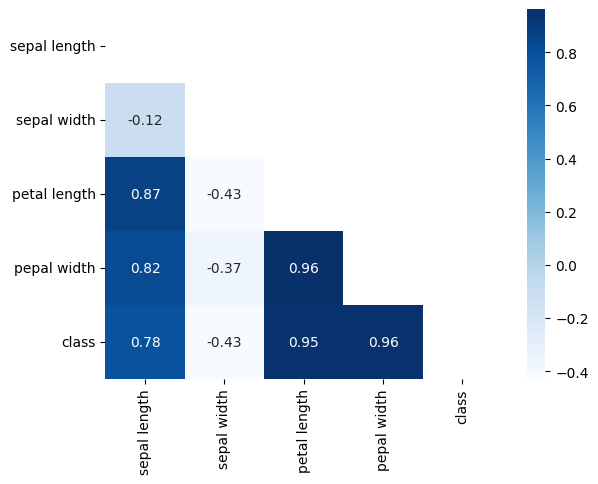

In [5]:
corr: Any = rmv_df.corr()
mask: np.ndarray[Any] = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="Blues", annot=True)

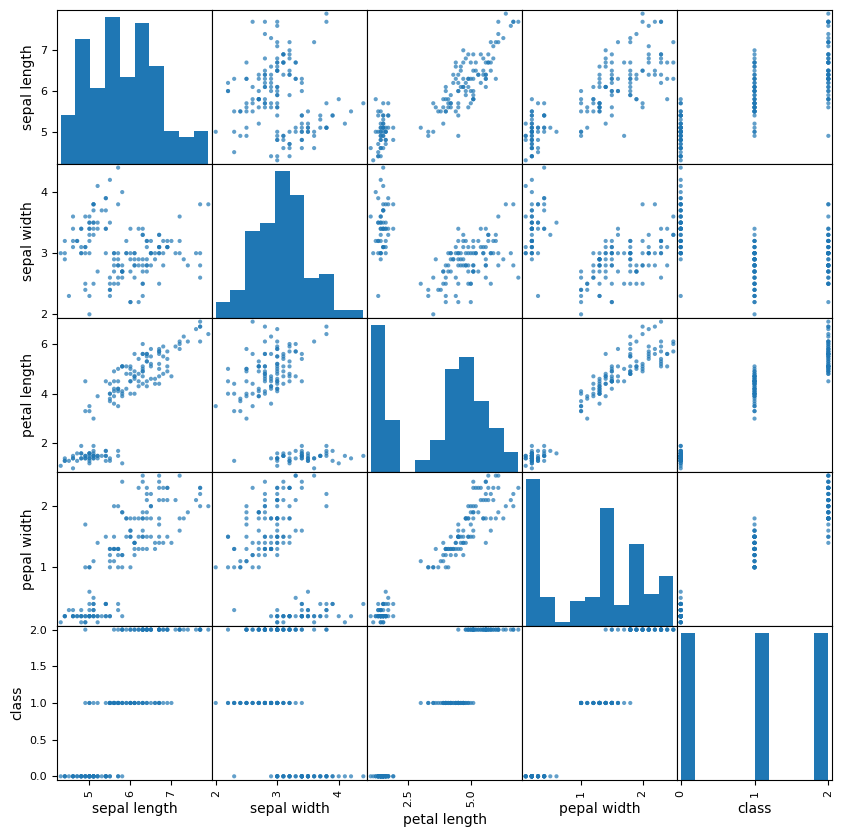

In [12]:
scatter_matrix = pd.plotting.scatter_matrix(df, alpha=0.7, figsize=(10, 10))

In [19]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=48)

In [20]:
def scores(y_data, y_predicted):
    print(f"Accuracy: {accuracy_score(y_data, y_predicted) * 100:.2f}")
    print(f"Recall: {recall_score(y_data, y_predicted, average='micro') * 100:.2f}")
    print(f"Precision: {precision_score(y_data, y_predicted, average='micro') * 100:.2f}")

## Work on raw data

In [27]:
clf = LogisticRegressionCV(cv=10, random_state=48, max_iter=1000)
clf.fit(X_train, y_train)

y_train_predicted = clf.predict(X_train)
y_test_predicted = clf.predict(X_test)

scores(y_train, y_train_predicted)
scores(y_test, y_test_predicted)

Accuracy: 98.00
Recall: 98.00
Precision: 98.00
Accuracy: 98.00
Recall: 98.00
Precision: 98.00
